In [1]:
import torch
from pipeline_klein_sde import Flux2KleinVPSDEPipeline
import gc
from PIL import Image, ImageOps
from diffusers.utils import make_image_grid
import time
from verifiers_utils import IDVerifier, LVFaceVerifier
from huggingface_hub import snapshot_download
from insightface.app import FaceAnalysis

device = "cuda"
dtype = torch.bfloat16

def flush():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_max_memory_allocated()
    torch.cuda.reset_peak_memory_stats()

/home_pers/jripoll/tfg_id_dino_klein/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-01 13:00:21.136684369 [W:onnxruntime:Default, device_discovery.cc:325 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:92 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [2]:
pipe = Flux2KleinVPSDEPipeline.from_pretrained("black-forest-labs/FLUX.2-klein-base-4B", torch_dtype=dtype,vae=None,transformer=None).to("cuda")
prompt = "this man is now playing guitar on a beach and wearing a hawaïan shirt, he is looking at the camera, has another pose and is smiling"
neg_prompt = ""
with torch.no_grad():
    prompt_embeds, _ = pipe.encode_prompt(prompt=prompt)
    negative_prompt_embeds, _ = pipe.encode_prompt(prompt=neg_prompt) 
del pipe
flush()

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|██████████| 3/3 [00:00<00:00,  3.09it/s]
/home_pers/jripoll/tfg_id_dino_klein/.venv/lib/python3.12/site-packages/torch/cuda/memory.py:489: FutureWarning: torch.cuda.reset_max_memory_allocated now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(


In [3]:
snapshot_download(
    "fal/AuraFace-v1",
    local_dir="models/auraface",
)
face_app = FaceAnalysis(
    name="auraface",
    providers=["CUDAExecutionProvider"],
    root=".",
)
face_app.prepare(ctx_id=0, det_size=(640, 640))
verifier = IDVerifier(face_app=face_app)
#verifier = LVFaceVerifier(face_app=face_app)

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 168.62it/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: ./models/auraface/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecu

In [4]:
dtype = torch.bfloat16
pipe = Flux2KleinVPSDEPipeline.from_pretrained("black-forest-labs/FLUX.2-klein-base-4B",torch_dtype=dtype,text_encoder=None,verifier=verifier).to("cuda")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|██████████| 4/4 [00:00<00:00,  8.06it/s]


In [5]:
image = Image.open("/home_pers/jripoll/self_guidance_f2k/charles.jpg")

In [6]:
pipe.transformer.requires_grad_(False)
pipe.transformer.enable_gradient_checkpointing()

pipe.vae.requires_grad_(False)
pipe.vae.enable_gradient_checkpointing()

/home_pers/jripoll/tfg_id_dino_klein/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
`height` and `width` have to be divisible by 16 but are 987 and 740. Dimensions will be resized accordingly
100%|██████████| 100/100 [03:09<00:00,  1.89s/it]


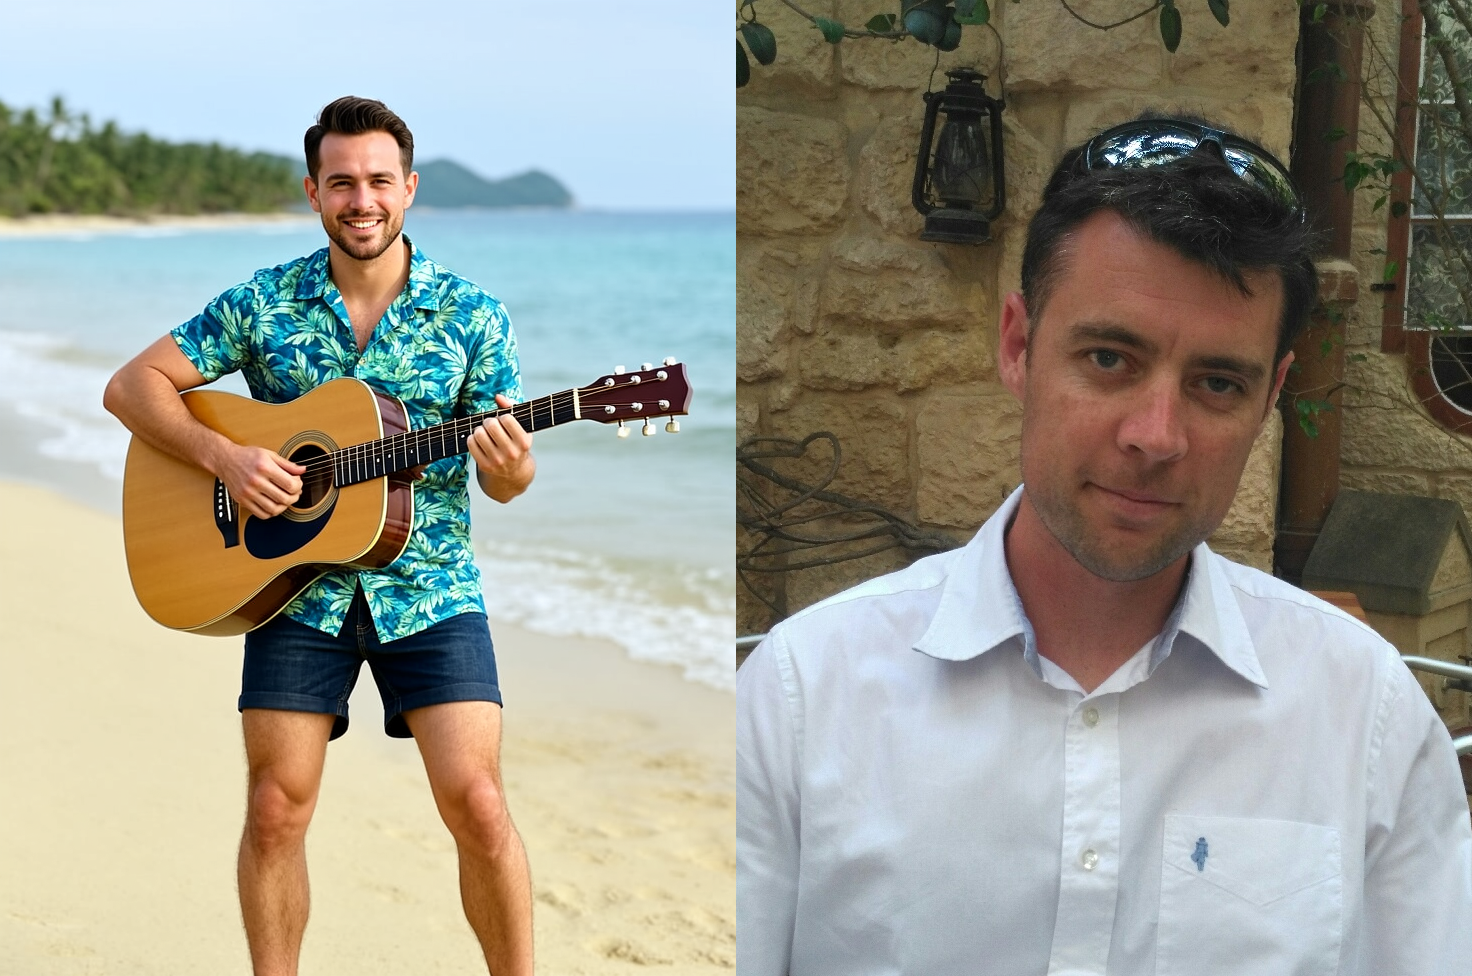

In [7]:
edited = pipe.guided_inference(
    prompt_embeds=prompt_embeds,
    negative_prompt_embeds=negative_prompt_embeds,
    image=image,
    height=image.size[1],
    width=image.size[0],
    guidance_scale=4.0,
    num_inference_steps=100,
    diffusion_norm=3.0,
    guidance_weight=25,
    drop_transformer_img_conditioning=True
).images[0]
display(make_image_grid([edited,image],rows=1,cols=2))